## **Filtros**

São técnicas amplamente usadas para **melhorar a qualidade, realçar características ou reduzir ruídos em imagens** antes de realizar análises ou outras tarefas de processamento.

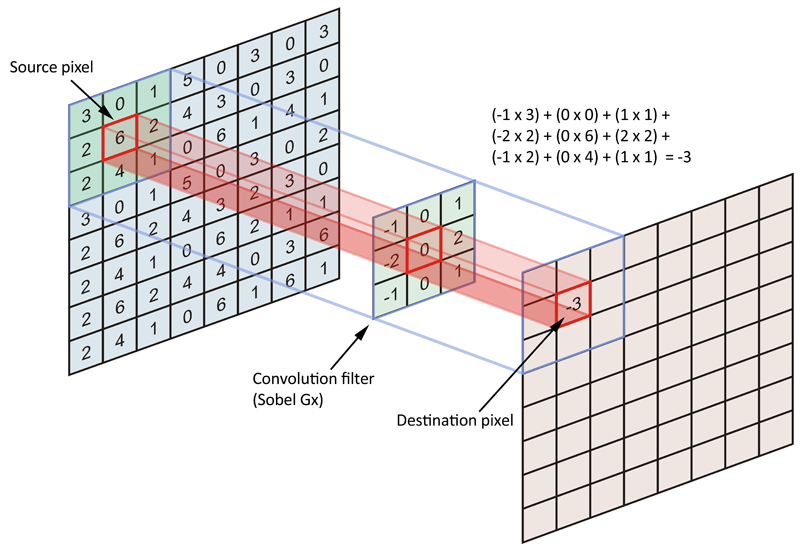

Esses filtros são aplicados a imagens para melhorar sua utilidade e legibilidade, tornando-as mais adequadas para terefas específicas, como **reconhecimento de objetos, segmentação, detecção de bordas, entre outras**.

In [276]:
import cv2
import matplotlib.pyplot as plt

In [277]:
def exibir_imagens(img1, img2, title1 = 'Imagem 1', title2 = 'Imagem 2'):

    _, ax = plt.subplots(1,2,figsize=(15,5))
    ax[0].imshow(img1, cmap = 'gray')
    ax[0].set_title(title1)

    ax[1].imshow(img2, cmap = 'gray')
    ax[1].set_title(title2)
    plt.show()

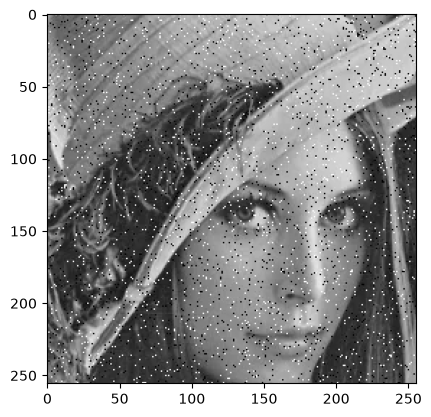

(256, 256)


In [278]:
image_path = 'images/image_noise.png'
image_gray1 = cv2.imread(image_path, 0)

plt.imshow(image_gray1, cmap='gray')
plt.show()

print(image_gray1.shape)

### **Filtro de média**

O filtro de média é o tipo mais simples de filtro de suavização. Ele funciona por convolução: uma janela (kernel) de tamanho n×n percorre a imagem, e para cada posição, o pixel central é substituído pela média aritmética dos valores de todos os pixels dentro da janela.

O efeito de usar o filtro de média é reduzir a variabilidade de níveis de cinza da imagem e suavizar o seu contraste (os detalhes são perdidos). O resultado é uma imagem com aparência um pouco desfocada.

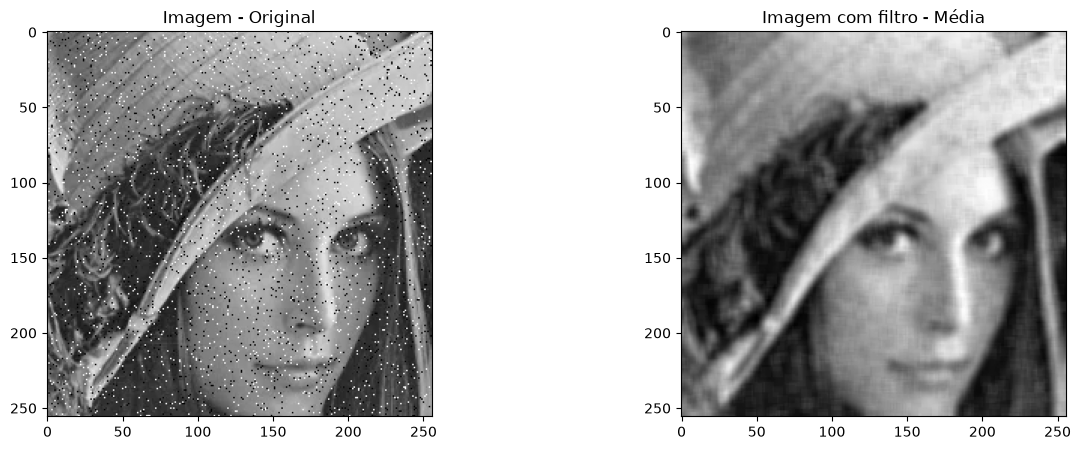

In [279]:
# Aplicando suavização com filtro da média

blurred_image_mean = cv2.blur(image_gray1, (7,7))

exibir_imagens(image_gray1, blurred_image_mean, title1='Imagem - Original', title2='Imagem com filtro - Média')

### **Filtro Gaussiano**

O filtro Gaussiano também faz uma média ponderada da vizinhança, mas os pesos não são uniformes — eles seguem uma distribuição normal (gaussiana), centrada no pixel de interesse. Isso significa que pixels mais próximos do centro têm peso maior, e pixels mais distantes têm peso menor.

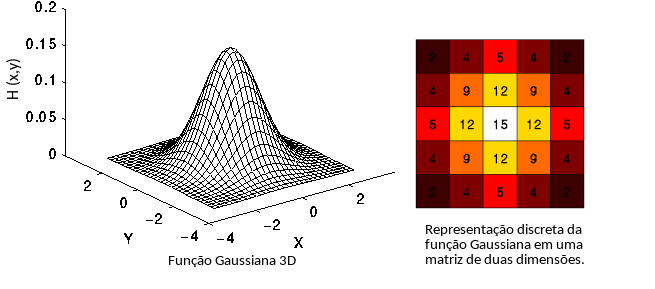

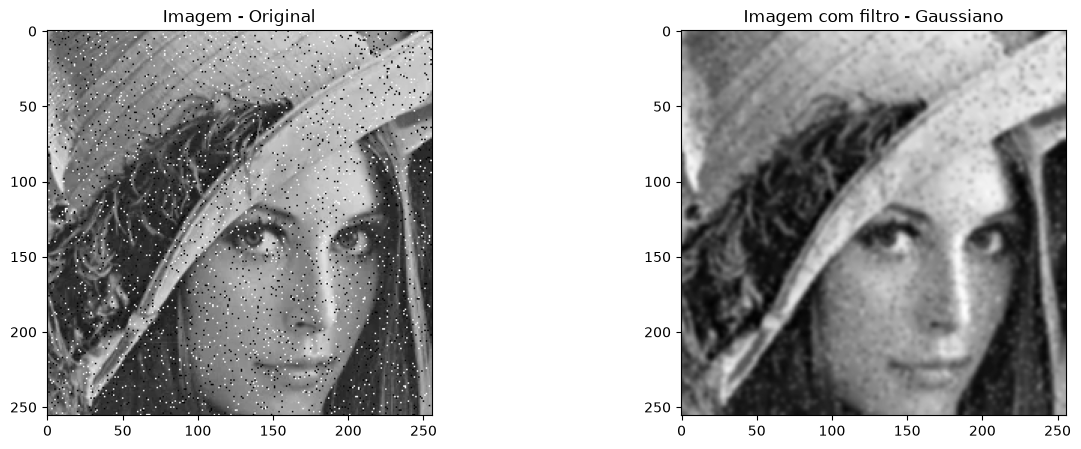

In [280]:
# Aplicando suavização com filtro gaussiano

blurred_image_gauss = cv2.GaussianBlur(image_gray1, (7,7), 0)

exibir_imagens(image_gray1, blurred_image_gauss, title1='Imagem - Original', title2='Imagem com filtro - Gaussiano')

### **Filtro de Mediana**

O valor mediano de um conjunto de pixels na vizinhança do pixel central é de tal forma que metade dos valores é menor que a mediana e a outra metade é maior.

- A mediana do conjunto de pixels é sempre igual a um dos valores presentes no conjunto de pixels.
- A mediana é menos sensível a pixels de valores extremos.

O filtro de mediana é bastante eficiente para suprimir um tipo de ruído chamado de sal e pimenta.

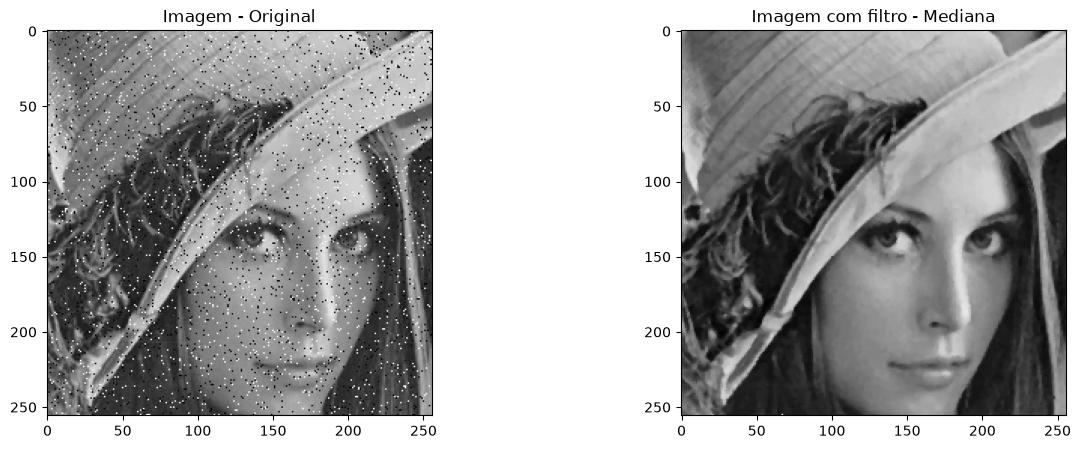

In [281]:
# Aplicando suavização com mediana

blurred_image_median = cv2.medianBlur(image_gray1, 3)

exibir_imagens(image_gray1, blurred_image_median, title1='Imagem - Original', title2='Imagem com filtro - Mediana')

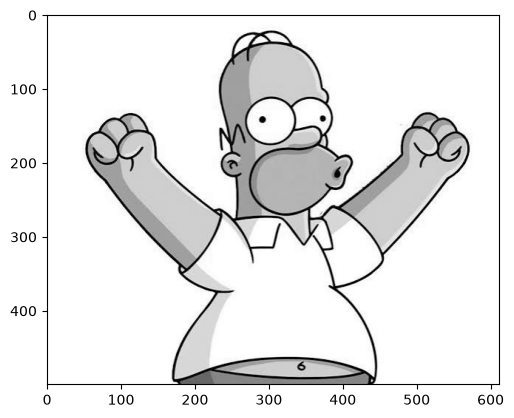

In [282]:
image_path = 'images/homer.png'
image_gray2 = cv2.imread(image_path, 0)

plt.imshow(image_gray2, cmap='gray')
plt.show()

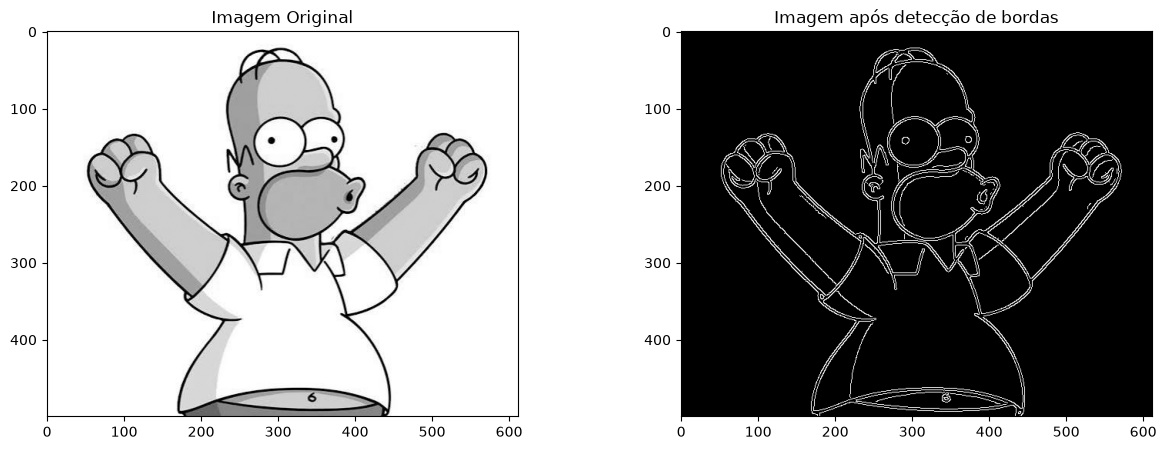

In [283]:
# Detecção de bordas

edge_canny = cv2.Canny(image_gray2, threshold1=100, threshold2=200)

exibir_imagens(image_gray2, edge_canny, title1='Imagem Original', title2='Imagem após detecção de bordas')

### **Equalização de Histograma**

Equalização de histograma é uma técnica que **redistribui** as intensidades dos pixels de forma que o histograma resultante fique o mais próximo possível de uma distribuição uniforme, espalhando os valores de intensidade por toda a faixa disponível (0-255).

O objetivo é aumentar o contraste global da imagem, especialmente útil quando a imagem está muito escura, muito clara, ou tem baixo contraste.

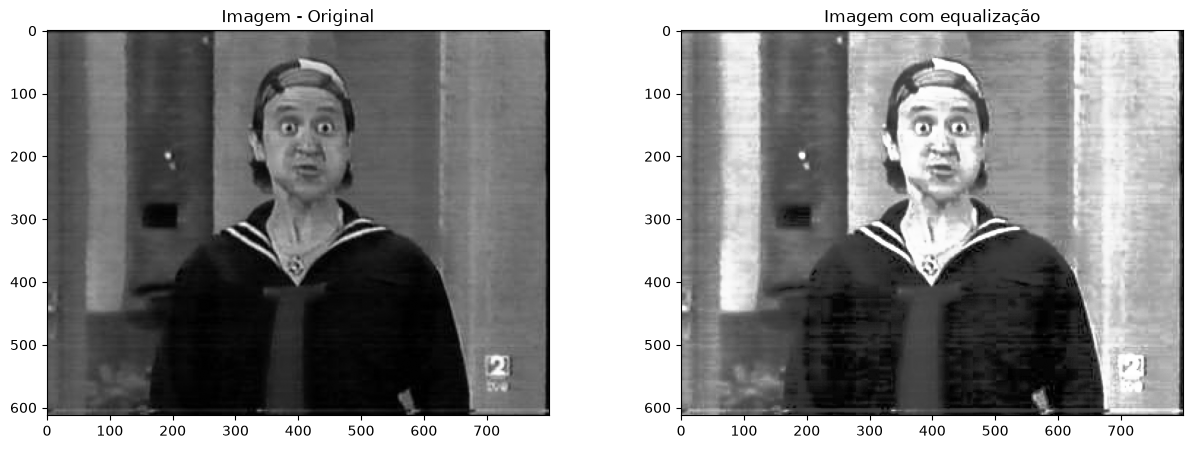

In [284]:
# Equalização do Histograma

image_path = 'images/img_exemplo.jpg'
image_gray3 = cv2.imread(image_path, 0)

img_eq_hist = cv2.equalizeHist(image_gray3)

exibir_imagens(image_gray3, img_eq_hist, title1='Imagem - Original', title2='Imagem com equalização')

A equalização de histograma global pode gerar resultados ruins em imagens com regiões de iluminação muito diferentes entre si, pois aplica a mesma transformação para a imagem toda. Para esses casos existe o CLAHE (Contrast Limited Adaptive Histogram Equalization), que aplica a equalização em blocos locais da imagem, limitando o quanto o contraste pode ser amplificado.

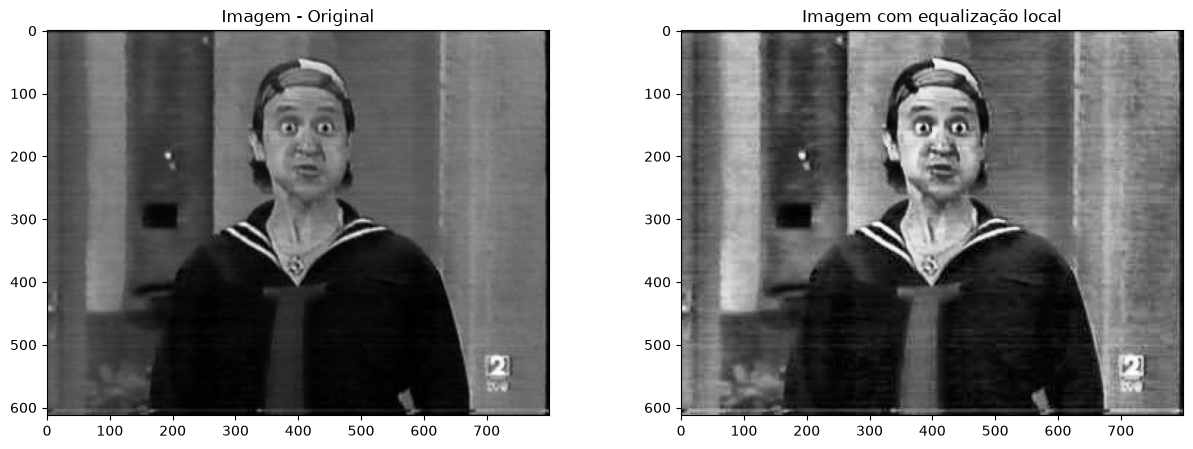

In [285]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(5,5))
img_clahe = clahe.apply(image_gray3)

exibir_imagens(image_gray3, img_clahe, title1='Imagem - Original', title2='Imagem com equalização local')